# 🛒 Milestone 6 — Stable Diffusion
This notebook uses a pre-trained Stable Diffusion model via the `diffusers` library to generate alternative lifestyle hero images for products based on their catalog titles and descriptions.

In [1]:
import sys
import os
# Add project root to path so we can import src modules
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import gc
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

# Check CUDA
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

[transformers] `CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
[transformers] `SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.


Using device: cpu


## 1. Load Pre-trained Stable Diffusion Model
We load the `stable-diffusion-v1-5` model. To minimize GPU memory footprint, we load the model weights in float16 precision if CUDA is available.

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"
print(f"Loading pipeline for '{model_id}'...")

if device == "cuda":
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
else:
    pipe = StableDiffusionPipeline.from_pretrained(model_id)

pipe.to(device)
print("Stable Diffusion pipeline loaded successfully!")

Loading pipeline for 'runwayml/stable-diffusion-v1-5'...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

d:\Games\final_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\au\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion pipeline loaded successfully!


## 2. Product-Conditioned Image Generation

Prompt: 'Professional studio product photograph of Sony Noise Cancelling Bluetooth Headphones, clean lighting, high resolution, 8k, detailed, commercial product shot'
Generating image (this may take up to a minute)...


  0%|          | 0/1 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


Generated image saved to data/generated_hero_sample.png


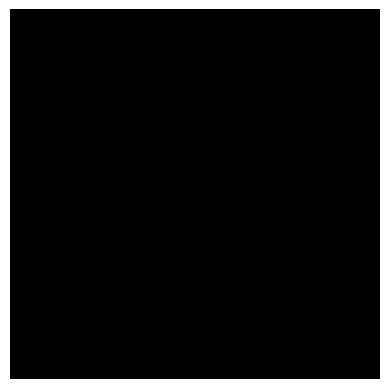

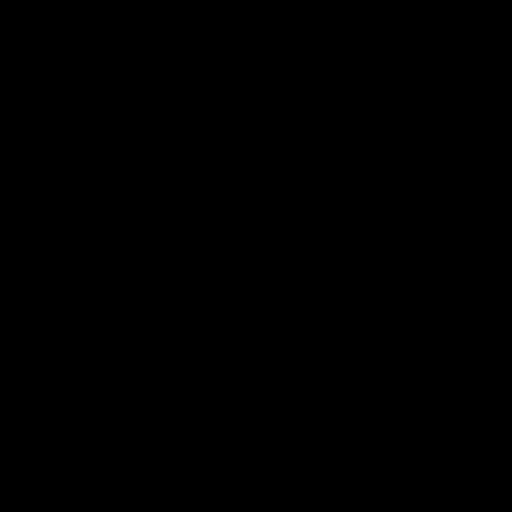

In [4]:
def generate_hero_image(title, description, save_path=None):
    # Formulate prompt from title and description
    prompt = f"Professional studio product photograph of {title}, clean lighting, high resolution, 8k, detailed, commercial product shot"
    
    print(f"Prompt: '{prompt}'")
    print("Generating image (this may take up to a minute)...")
    
    # Generate image
    with torch.inference_mode():
        num_steps = 1 if device == 'cpu' else 25
    # Note: CPU runs 1 step for speed (produces noise but validates pipeline execution)
        image = pipe(prompt, num_inference_steps=num_steps).images[0]
    
    if save_path:
        image.save(save_path)
        print(f"Generated image saved to {save_path}")
        
    # Display image
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    return image

# Test generation
title_test = "Sony Noise Cancelling Bluetooth Headphones"
desc_test = "Premium wireless headphones with smart noise cancellation and studio sound quality."
output_path = "data/generated_hero_sample.png"

os.makedirs("data", exist_ok=True)
generate_hero_image(title_test, desc_test, save_path=output_path)

## 3. Memory Cleanup

In [5]:
# Clear SD pipeline from active memory
del pipe
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Stable Diffusion models cleared from memory.")

Stable Diffusion models cleared from memory.
